#### Retail Sales Performance Analysis & Business Insights
#### 1. Problem Statement  

The dataset contains over 10,000 sales records across multiple regions, categories, and customer segments.

Analyze sales data to identify key factors affecting revenue and profitability, uncover trends across regions and products, and provide actionable business recommendations to improve performance.

In [235]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [219]:
df=pd.read_csv("samplesuperstore.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


#### 2. Data Understanding  

In [220]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [221]:
df.isna().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [222]:
df.duplicated().sum()

np.int64(0)

No missing values and no duplicate rows found in the dataset.

In [223]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


#### 3. Data Cleaning  

In [224]:
date_cols=["Order Date","Ship Date"]
df[date_cols]=df[date_cols].apply(pd.to_datetime)

In [225]:
df["Order Date"].dtype
df["Ship Date"].dtype

dtype('<M8[ns]')

#### 4. Feature Engineering:

In [226]:
df["Order Year"]=df["Order Date"].dt.year
df["Order Month"]=df["Order Date"].dt.strftime("%b")
df["Profit Margin"]=np.where(df["Sales"]!=0,(df["Profit"]/df["Sales"])*100,0)

Feature engineering was performed to extract time-based insights (Year, Month) and calculate Profit Margin, a key metric to evaluate business efficiency.

In [227]:
df["Month Year"]=df["Order Date"].dt.to_period("M").dt.to_timestamp()

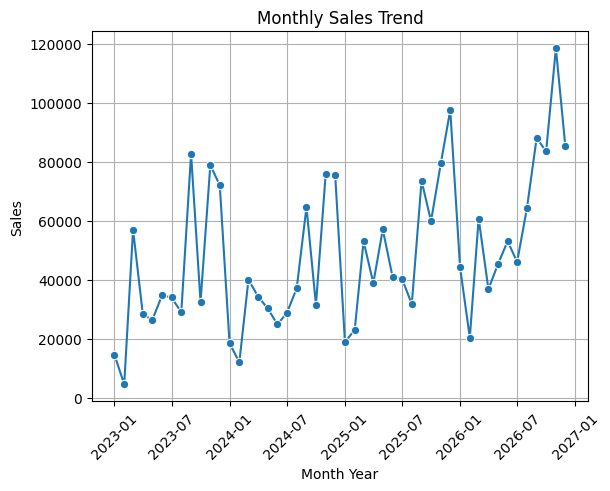

In [228]:
monthly_sales=df.groupby("Month Year")["Sales"].sum().reset_index()
monthly_sales=monthly_sales.sort_values("Month Year")
sns.lineplot(data=monthly_sales,x="Month Year",y="Sales",marker="o")
plt.title("Monthly Sales Trend")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

#### 5. Exploratory Data Analysis & Key Insights

The monthly sales trend shows significant fluctuations, indicating inconsistent demand patterns. While there are periodic spikes, no single month consistently dominates as a peak season. However, overall sales show an upward trend in later periods, suggesting business growth despite volatility.

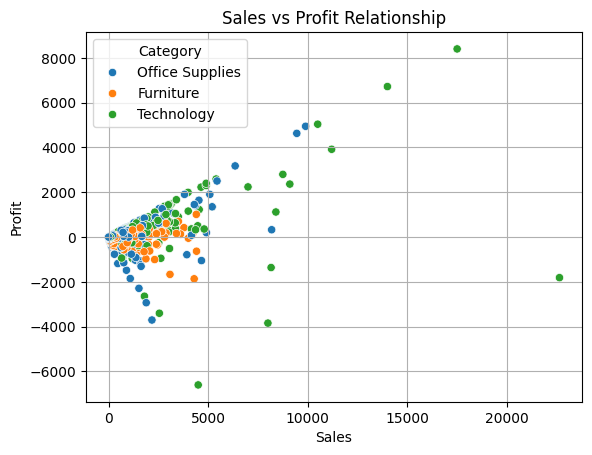

In [229]:
sns.scatterplot(data=df,x="Sales",y="Profit",hue="Category")
plt.title("Sales vs Profit Relationship")
plt.grid(True)
plt.show()

The analysis reveals that higher sales do not necessarily translate into higher profits, indicating inefficiencies in pricing or discount strategies. Notably, the Furniture category shows several instances of high sales but negative profit, suggesting potential losses. In contrast, Technology products tend to generate higher profits, making them a key driver of business profitability.

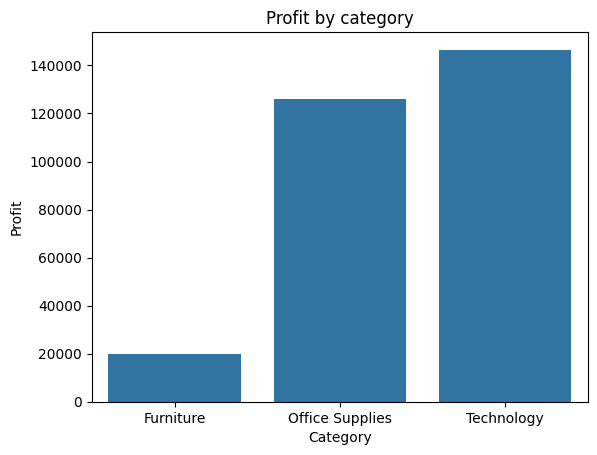

In [230]:
categor_data=df.groupby("Category")[["Sales","Profit"]].sum().reset_index()
sns.barplot(data=categor_data,x="Category",y="Profit")
plt.title("Profit by category")
plt.show()

Technology is the most profitable category and acts as the primary profit driver for the business. Office Supplies also contribute steady profits. However, Furniture generates significantly lower profit despite sales, indicating inefficiencies such as high discounts or costs. The company should optimize or reassess its Furniture category strategy rather than simply increasing focus on it.

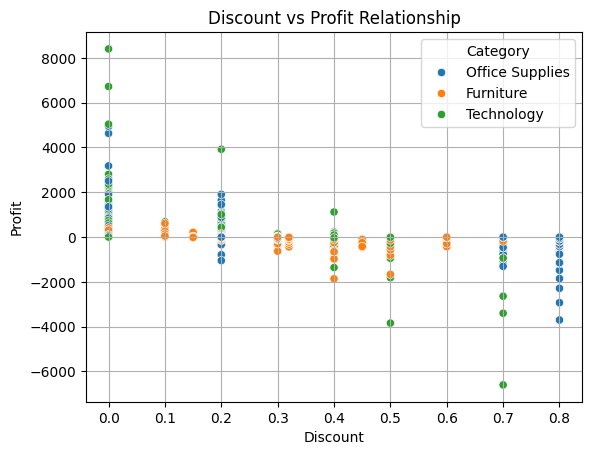

In [231]:
sns.scatterplot(data=df,x="Discount",y="Profit",hue="Category")
plt.title("Discount vs Profit Relationship")
plt.grid(True)
plt.show()

The analysis shows a clear negative relationship between discount and profit, where higher discounts significantly reduce profitability. This effect is most severe in the Furniture category, which incurs losses even at moderate discount levels. While Technology and Office Supplies perform better at lower discounts, excessive discounting leads to losses across all categories. This suggests that current discount strategies are negatively impacting overall profitability.

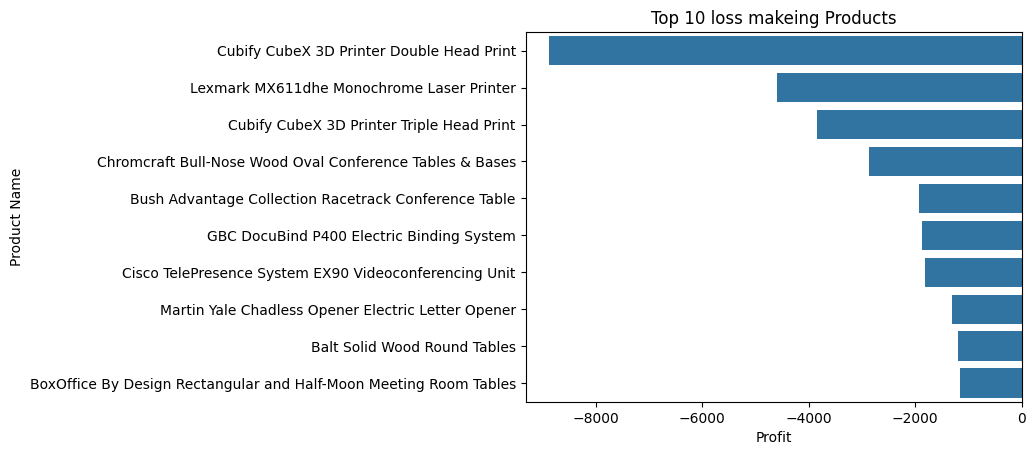

In [ ]:
loss_prod=df.groupby("Product Name")["Profit"].sum().reset_index()
loss_prod=loss_prod.sort_values(by="Profit").head(10)
sns.barplot(data=loss_prod,x="Profit",y="Product Name")
plt.title("Top 10 Loss-Making Products")
plt.show()

Certain products consistently generate losses and should be reviewed for pricing, discount strategy, or potential removal from the product portfolio.

#### 6. Recommendations:
**1. Optimize Furniture Category Strategy-**
The Furniture category requires immediate attention as it generates low or negative profit despite sales. The company should reassess pricing, reduce excessive discounting, and optimize cost structure to improve profitability.

**2. Control Discount Strategy-**
High discounts are significantly impacting profitability across all categories. The business should implement stricter discount policies and avoid heavy discounting, especially in low-margin products.

**3. Focus on High-Profit Categories-**
Technology is the most profitable category and should be prioritized for growth through targeted marketing, promotions, and inventory expansion to maximize revenue and profit.

**4. Balance Sales and Profitability-**
Increasing sales alone is not sufficient; the company must focus on profitable sales by maintaining a balance between pricing, discounts, and cost efficiency.

**5. Monitor Regional and Product-Level Performance-**
Further analysis should be conducted at regional and product levels to identify underperforming areas and optimize business strategies accordingly.

#### 7. Final Conclusion
Overall, the primary driver of profitability issues in the business is excessive discounting, particularly within the Furniture category, which leads to high sales but low or negative profit.